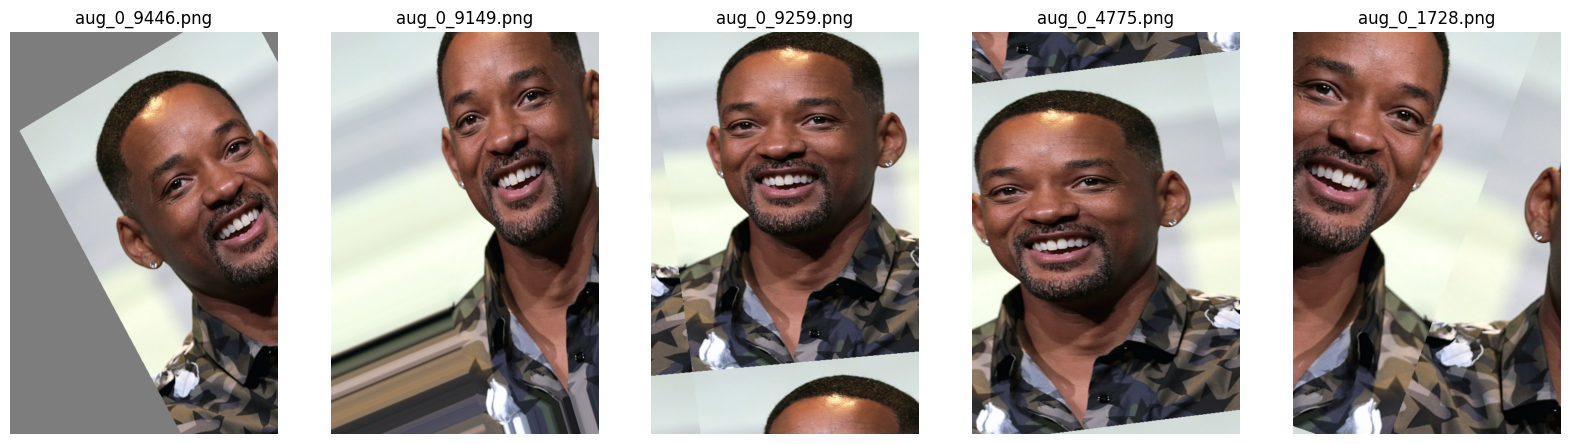

Augmented images are saved to /content/augmented


In [6]:
# Import required libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import os
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

# Construct an instance of the ImageDataGenerator class
# Pass the augmentation parameters through the constructor.
datagen = ImageDataGenerator(
    rotation_range=20,     # Random rotation between 0 and 45
    width_shift_range=0.2,   # % shift
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='wrap',
    cval=125  # Try other modes like 'nearest', 'constant', 'reflect', 'wrap'
)

# Create the directory for saving augmented images if it does not exist
output_dir = '/content/augmented'
os.makedirs(output_dir, exist_ok=True)

# Loading a sample image
x = io.imread('/content/Will_Smith_by_Gage_Skidmore.jpg')  # Replace with your image path

# Reshape the input image because `datagen.flow` requires a 4D array
# First element represents the number of images
x = x.reshape((1,) + x.shape)  # (1, 256, 256, 3)

# Variable to count the number of batches generated
i = 0
for batch in datagen.flow(x, batch_size=16,
                          save_to_dir=output_dir,
                          save_prefix='aug',
                          save_format='png'):
    i += 1
    if i > 20:  # Stop after 20 batches (so 320 images are saved)
        break  # Otherwise, the generator will loop indefinitely

# Display some of the saved augmented images
augmented_images = os.listdir(output_dir)
random_images = random.sample(augmented_images, 5)  # Select 5 random images to display

# Plot images
fig, axes = plt.subplots(1, 5, figsize=(20, 20))
for ax, img_file in zip(axes, random_images):
    img_path = os.path.join(output_dir, img_file)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # Turn off axis
    ax.set_title(img_file)

plt.show()

# Output the location of saved images
print(f"Augmented images are saved to {output_dir}")